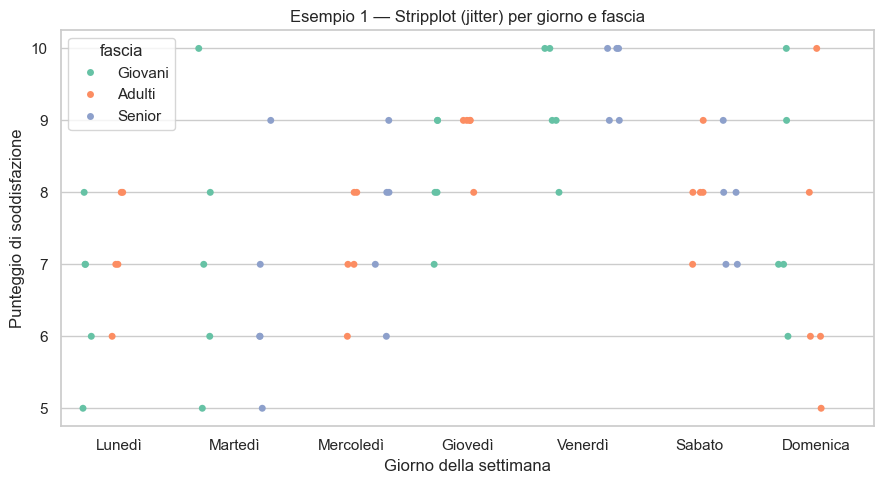

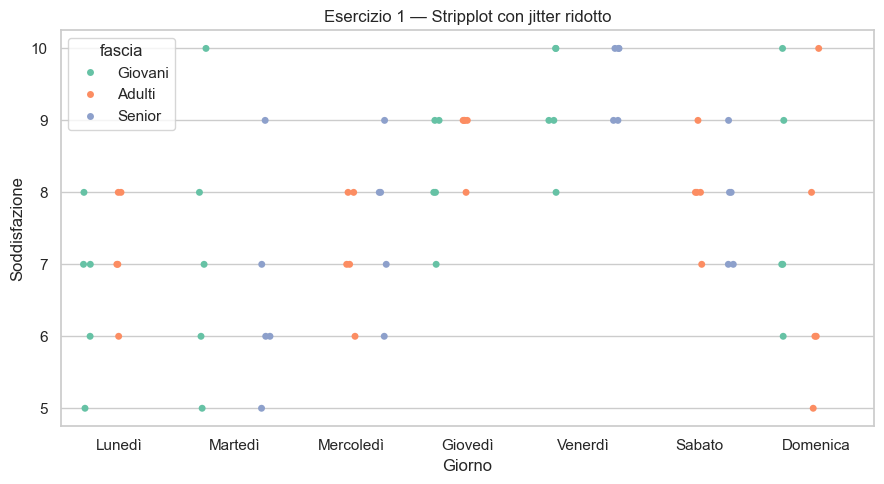

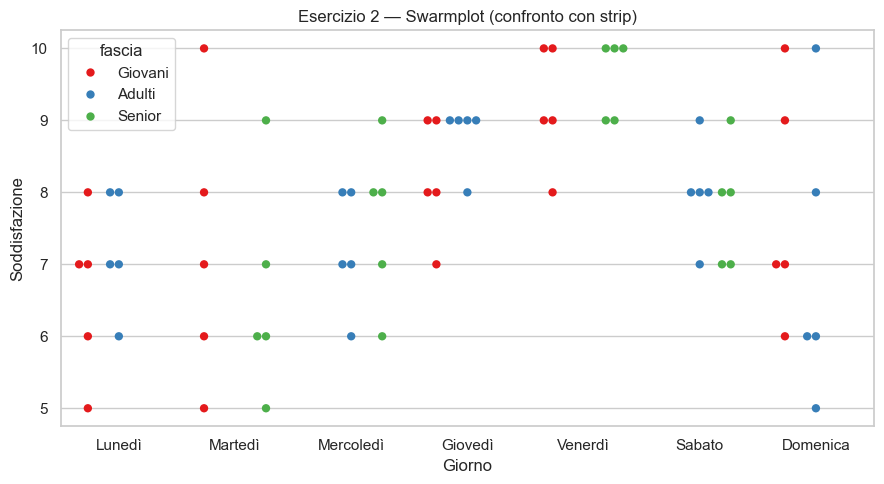

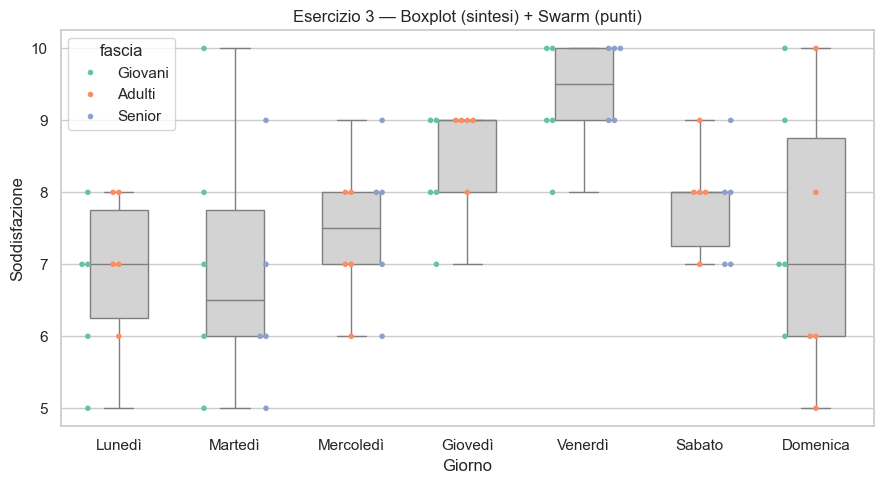

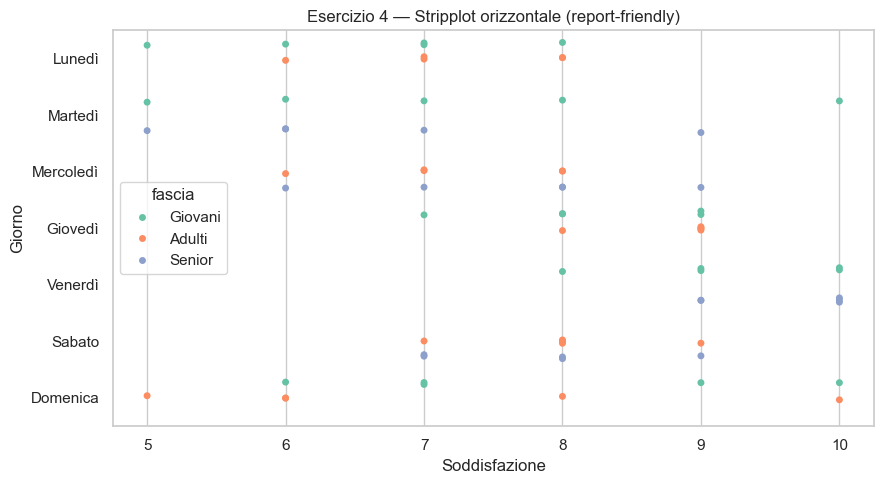

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 0) Dataset (uguale al prompt)
# -----------------------------
df = pd.DataFrame({
    "giorno": [
        "Lunedì", "Lunedì", "Martedì", "Martedì", "Mercoledì", "Mercoledì",
        "Giovedì", "Giovedì", "Venerdì", "Venerdì", "Sabato", "Sabato", "Domenica", "Domenica"
    ] * 5,
    "soddisfazione": [
        7, 8, 6, 7, 8, 9, 7, 8, 9, 10, 8, 9, 7, 8,
        6, 7, 5, 6, 8, 8, 9, 9, 10, 10, 9, 8, 7, 6,
        5, 6, 7, 8, 6, 7, 8, 9, 9, 8, 8, 7, 6, 5,
        7, 8, 9, 10, 7, 6, 8, 9, 10, 9, 7, 8, 9, 10,
        8, 7, 6, 5, 7, 8, 9, 9, 10, 9, 8, 7,10, 6
    ][:70],
    "fascia": [
        "Giovani", "Adulti", "Senior", "Giovani", "Adulti", "Senior", "Giovani",
        "Adulti", "Senior", "Giovani", "Adulti", "Senior", "Giovani", "Adulti"
    ] * 5
})

# Ordine categorie (leggibilità)
giorni = ["Lunedì","Martedì","Mercoledì","Giovedì","Venerdì","Sabato","Domenica"]
fasce  = ["Giovani","Adulti","Senior"]

df["giorno"] = pd.Categorical(df["giorno"], categories=giorni, ordered=True)
df["fascia"] = pd.Categorical(df["fascia"], categories=fasce, ordered=True)

# -----------------------------
# 1) Setup grafico + output
# -----------------------------
sns.set_theme(style="whitegrid")  # look pulito (modificabile)
OUTDIR = "plots_2_404"
os.makedirs(OUTDIR, exist_ok=True)



# -----------------------------
# ESEMPIO 1 — Stripplot
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 5))
sns.stripplot(
    data=df, x="giorno", y="soddisfazione",
    hue="fascia", dodge=True, jitter=0.2,
    palette="Set2", size=5, ax=ax
)
ax.set_title("Esempio 1 — Stripplot (jitter) per giorno e fascia")
ax.set_xlabel("Giorno della settimana")
ax.set_ylabel("Punteggio di soddisfazione")
plt.tight_layout()
plt.show()


# -----------------------------
# ESERCIZIO 1 — Stripplot con jitter più controllato
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 5))
sns.stripplot(
    data=df, x="giorno", y="soddisfazione",
    hue="fascia", dodge=True, jitter=0.12,
    palette="Set2", size=5, ax=ax
)
ax.set_title("Esercizio 1 — Stripplot con jitter ridotto")
ax.set_xlabel("Giorno")
ax.set_ylabel("Soddisfazione")
plt.tight_layout()
plt.show()


# -----------------------------
# ESERCIZIO 2 — Swarmplot (stessa distribuzione)
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 5))
sns.swarmplot(
    data=df, x="giorno", y="soddisfazione",
    hue="fascia", dodge=True,
    palette="Set1", size=6, ax=ax
)
ax.set_title("Esercizio 2 — Swarmplot (confronto con strip)")
ax.set_xlabel("Giorno")
ax.set_ylabel("Soddisfazione")
plt.tight_layout()
plt.show()


# -----------------------------
# ESERCIZIO 3 — Boxplot + Swarm overlay
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df, x="giorno", y="soddisfazione",
    color="lightgray", width=0.5, ax=ax
)
sns.swarmplot(
    data=df, x="giorno", y="soddisfazione",
    hue="fascia", dodge=True,
    palette="Set2", size=4, ax=ax
)
ax.set_title("Esercizio 3 — Boxplot (sintesi) + Swarm (punti)")
ax.set_xlabel("Giorno")
ax.set_ylabel("Soddisfazione")
plt.tight_layout()
plt.show()


# -----------------------------
# ESERCIZIO 4 — Variante “report”: orientamento orizzontale
# (spesso migliora la leggibilità su categorie lunghe)
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 5))
sns.stripplot(
    data=df, y="giorno", x="soddisfazione",
    hue="fascia", dodge=True, jitter=0.12,
    palette="Set2", size=5, ax=ax
)
ax.set_title("Esercizio 4 — Stripplot orizzontale (report-friendly)")
ax.set_xlabel("Soddisfazione")
ax.set_ylabel("Giorno")
plt.tight_layout()
plt.show()

